# Explore here

In [17]:
# Your code here
import pandas as pd
from sklearn.model_selection import train_test_split

# se cargan los datos
url = "https://raw.githubusercontent.com/4GeeksAcademy/decision-tree-project-tutorial/main/diabetes.csv"
df = pd.read_csv(url)

#  se separar X y y
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# División (mantenemos el random_state=42 para que los resultados sean comparables)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Datos cargados y listos para el Bosque.")




Datos cargados y listos para el Bosque.


In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# se crear el modelo de Bosque Aleatorio
# Probaremos con 100 árboles para empezar
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)

#Entrenar
model_rf.fit(X_train, y_train)

# Predecir y medir
y_pred_rf = model_rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

print(f"Precisión del Random Forest inicial: {acc_rf * 100:.2f}%")

Precisión del Random Forest inicial: 72.08%


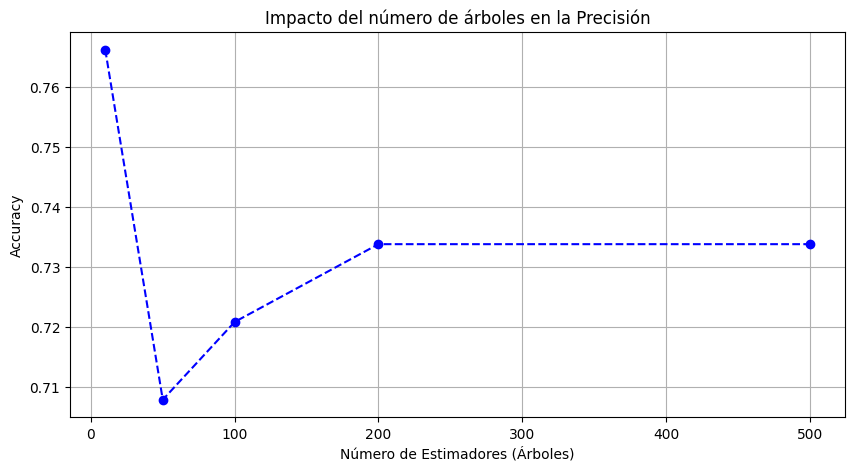

In [19]:
import matplotlib.pyplot as plt

# se prueban diferentes cantidades de árboles
estimadores = [10, 50, 100, 200, 500]
resultados = []

for n in estimadores:
    modelo = RandomForestClassifier(n_estimators=n, random_state=42)
    modelo.fit(X_train, y_train)
    acc = accuracy_score(y_test, modelo.predict(X_test))
    resultados.append(acc)

# Graficar las conclusiones
plt.figure(figsize=(10,5))
plt.plot(estimadores, resultados, marker='o', linestyle='--', color='b')
plt.title("Impacto del número de árboles en la Precisión")
plt.xlabel("Número de Estimadores (Árboles)")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

In [22]:
from pickle import dump

# se guarda este nuevo modelo 
with open("diabetes_random_forest_final.sav", "wb") as f:
    dump(model_rf, f)

print("¡Modelo Random Forest guardado con éxito!")



¡Modelo Random Forest guardado con éxito!


/tmp/ipykernel_1057/2088614272.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=df_importancia, palette='magma')


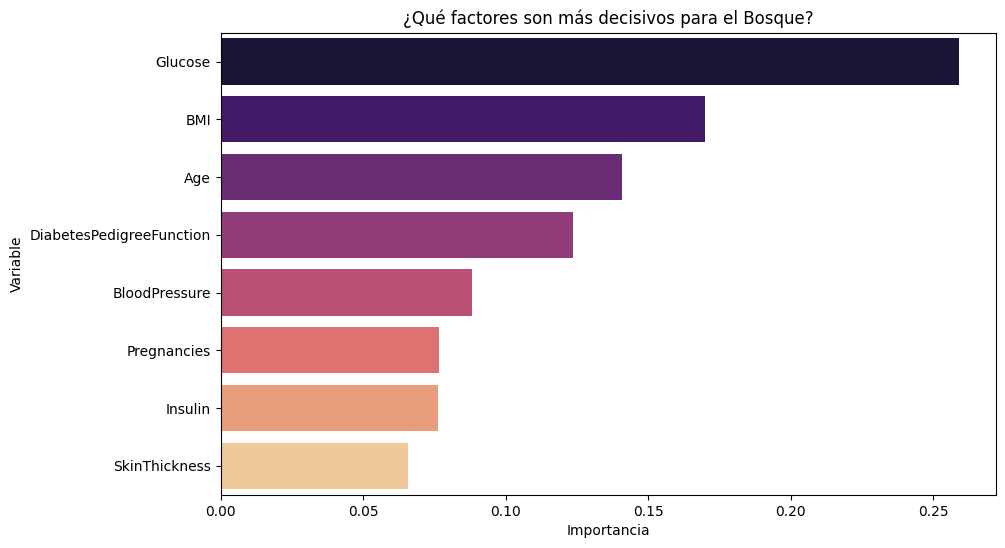

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# se extrae la importancia de las variables del bosque
importancias = model_rf.feature_importances_
variables = X.columns

# se crear un DataFrame para graficar mejor
df_importancia = pd.DataFrame({'Variable': variables, 'Importancia': importancias}).sort_values(by='Importancia', ascending=False)

# Graficar
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=df_importancia, palette='magma')
plt.title("¿Qué factores son más decisivos para el Bosque?")
plt.show()

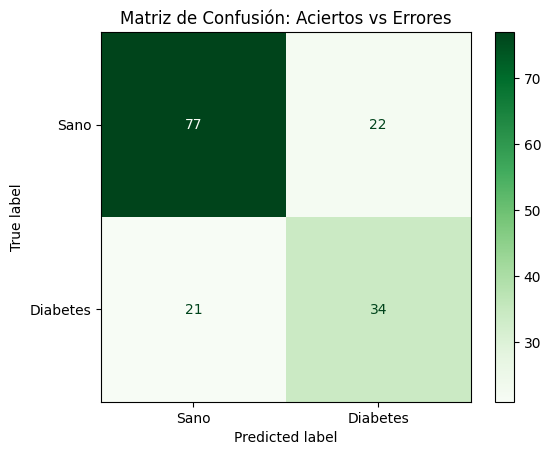

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generar la matriz
cm = confusion_matrix(y_test, y_pred_rf)

# Dibujarla
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Sano", "Diabetes"])
disp.plot(cmap='Greens')
plt.title("Matriz de Confusión: Aciertos vs Errores")
plt.show()

In [24]:
from pickle import dump

# Guardamos este nuevo modelo 
with open("diabetes_random_forest_final.sav", "wb") as f:
    dump(model_rf, f)

print("¡Modelo Random Forest guardado con éxito n2!")

¡Modelo Random Forest guardado con éxito n2!
